In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM, coint_johansen
from statsmodels.tsa.stattools import adfuller

In [168]:
data = pd.read_csv('data/data.csv')
data['quarter'] = pd.PeriodIndex(data['quarter'], freq='Q')
data = data.set_index('quarter')
data = data.dropna()

data.head()

,real_GDP,cpi_level,unemp_rate,agg_deposits,base_rate,cpi_rate
quarter,,,,,,
2001Q1,457680,53.8,5.1,7.7,5.86,0.938086
2001Q2,459620,54.6,5.0,8.5,5.36,1.486989
2001Q3,462016,54.6,5.1,8.4,5.05,1.486989
2001Q4,463404,54.6,5.2,8.4,4.23,0.924214
2002Q1,464698,54.6,5.2,8.1,4.00,1.486989


## VECM

In [169]:
df = data.copy()

df['real_GDP'] = np.log(df['real_GDP'])
df['cpi_rate'] = df['cpi_rate'].replace(0, 1e-6)
df['agg_deposits'] = np.log(df['agg_deposits'])
df['base_rate'] = df['base_rate']
df['unemp_rate'] = df['unemp_rate']
df = (df - df.mean()) / df.std()

# real_gdp → cpi_rate → unemp_rate → agg_deposits → base_rate
# df = df[['real_GDP', 'cpi_rate', 'unemp_rate', 'agg_deposits', 'base_rate']]
# df = df[['base_rate', 'cpi_rate', 'unemp_rate', 'agg_deposits']]
df = df[['base_rate', 'cpi_rate', 'real_GDP', 'agg_deposits']]
# df = df[['real_GDP', 'cpi_rate', 'base_rate', 'agg_deposits']]
df = df[['real_GDP', 'base_rate', 'cpi_rate', 'agg_deposits']]
df = df[['base_rate', 'real_GDP', 'cpi_rate', 'agg_deposits']]

df = df.dropna()

In [170]:
df = (df - df.mean()) / df.std()
df = df[['base_rate', 'real_GDP', 'cpi_rate', 'agg_deposits']].dropna()

adf_results = []

for col in df.columns:
    result = adfuller(df[col])

    adf_results.append({
        'Variable': col,
        'ADF Statistic': result[0],
        'p-value': result[1],
    })

# convert to dataframe
adf_df = pd.DataFrame(adf_results)

# optional formatting
adf_df['ADF Statistic'] = adf_df['ADF Statistic'].round(3)
adf_df['p-value'] = adf_df['p-value'].round(3)

adf_df

,Variable,ADF Statistic,p-value
0,base_rate,-1.798,0.381
1,real_GDP,-1.382,0.591
2,cpi_rate,-1.857,0.353
3,agg_deposits,-1.705,0.428


In [171]:
# collect ADF results
adf_results = []

for col in df.columns:
    result = adfuller(df[col])

    adf_results.append({
        'Variable': col,
        'ADF Statistic': result[0],
        'p-value': result[1],
    })

# convert to dataframe
adf_df = pd.DataFrame(adf_results)

# optional formatting
adf_df['ADF Statistic'] = adf_df['ADF Statistic'].round(3)
adf_df['p-value'] = adf_df['p-value'].round(3)

In [172]:
for col in df.columns:
    result = adfuller(df[col].diff().dropna(), autolag='AIC')
    print(f"{col}: ADF stat={result[0]:.3f}, p={result[1]:.3f}")

base_rate: ADF stat=-3.862, p=0.002
real_GDP: ADF stat=-9.013, p=0.000
cpi_rate: ADF stat=-3.821, p=0.003
agg_deposits: ADF stat=-5.489, p=0.000


In [173]:
var_model = VAR(df)
lag_order = var_model.select_order(maxlags=4)
print(lag_order.summary())

p=2

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -0.8033     -0.6936      0.4479     -0.7590
1      -10.38      -9.831   3.107e-05      -10.16
2      -11.23     -10.25*   1.327e-05     -10.83*
3      -11.22      -9.798   1.346e-05      -10.65
4     -11.29*      -9.421  1.277e-05*      -10.53
-------------------------------------------------


In [174]:
result = coint_johansen(df, det_order=1, k_ar_diff=p-1)
print(result.lr1)   # trace statistics
print(result.cvt)   # critical values

r=2

[74.12868438 36.63682373 17.52708934  4.16039491]
[[51.6492 55.2459 62.5202]
 [32.0645 35.0116 41.0815]
 [16.1619 18.3985 23.1485]
 [ 2.7055  3.8415  6.6349]]


In [175]:
vecm = VECM(df, k_ar_diff=p-1, coint_rank=r, deterministic='co')
vecm_fit = vecm.fit()
print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation base_rate
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0003      0.014     -0.023      0.982      -0.028       0.027
L1.base_rate        0.6363      0.081      7.820      0.000       0.477       0.796
L1.real_GDP        -0.0026      0.049     -0.053      0.958      -0.098       0.093
L1.cpi_rate        -0.0258      0.051     -0.501      0.616      -0.127       0.075
L1.agg_deposits     0.0193      0.042      0.458      0.647      -0.063       0.102
Det. terms outside the coint. relation & lagged endog. parameters for equation real_GDP
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0485      0.030      1.603      0.109      -0

In [176]:
irf = vecm_fit.irf(20)

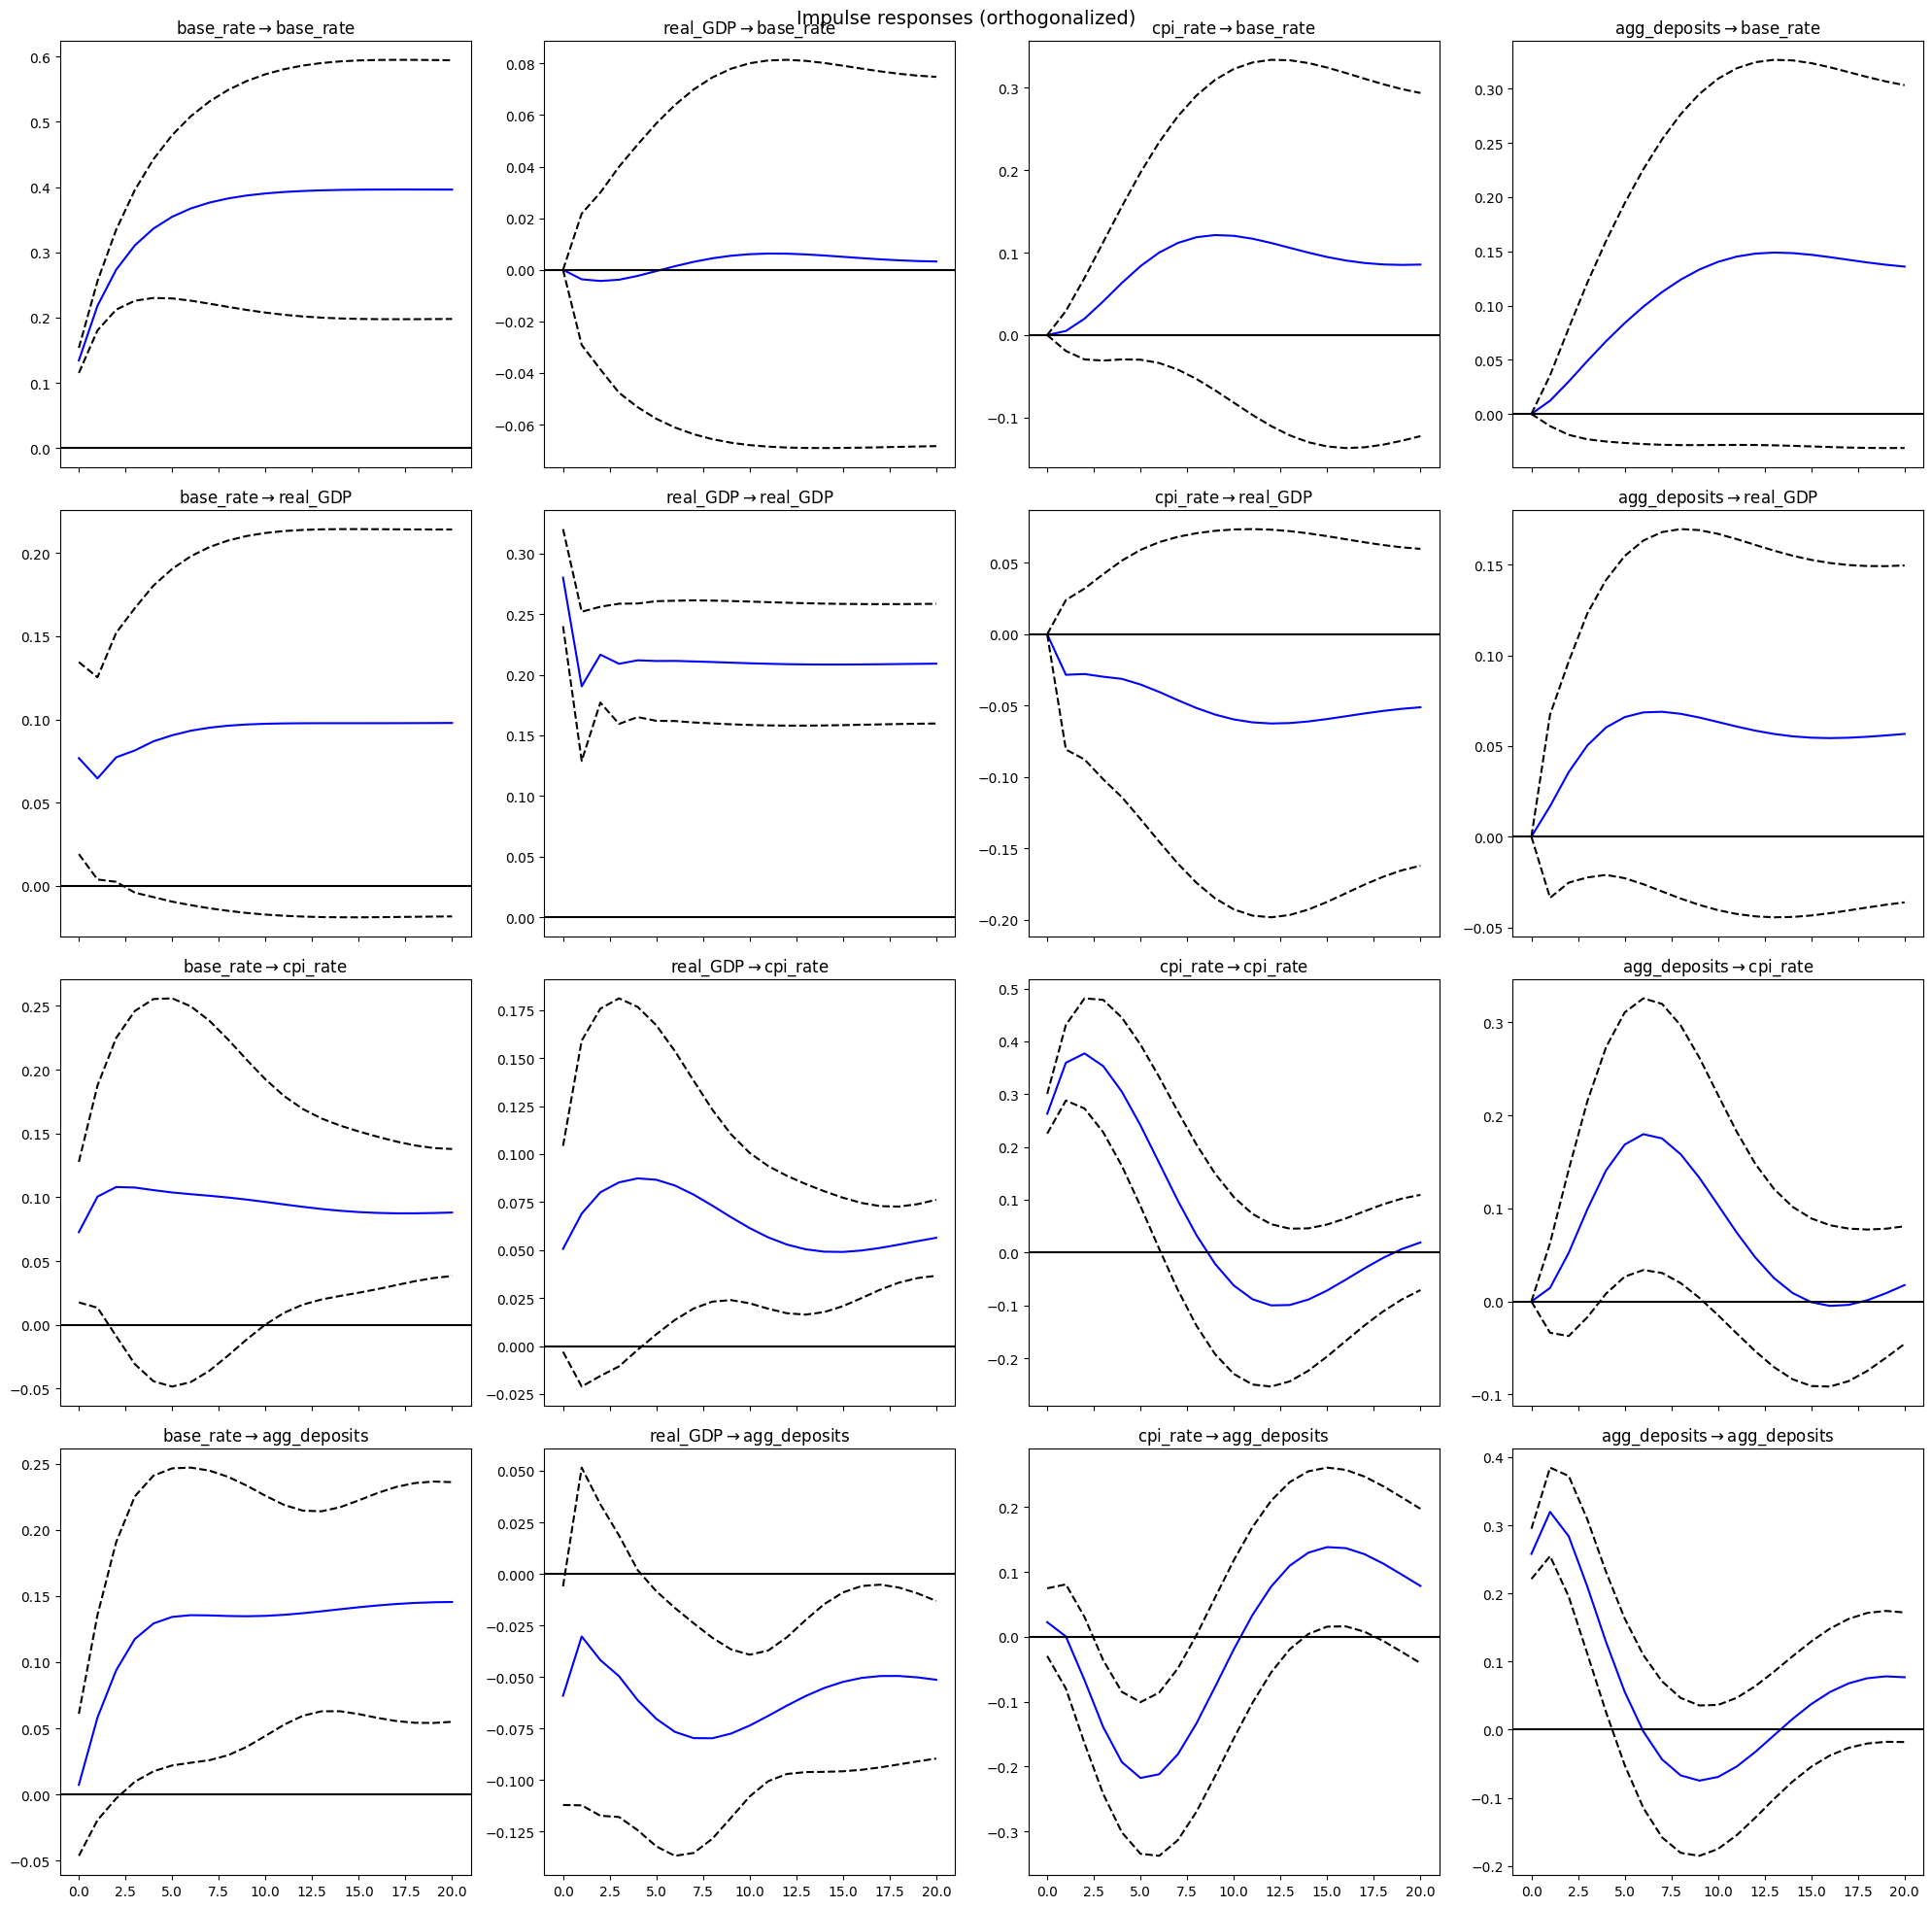

In [177]:
irf.plot(figsize=(20,20), orth=True)
plt.tight_layout()
plt.show()